# Structural keys and fingerprints

Reprezentations:
* structural key
    * predefined vector (e.g., bit 5 = Nitro group)
    * small
* fingerprint
    * algorithmic/Hashed (No fixed meaning)
    * large
    * collisions - different molecules may have the same fingerprint

### RDKit fingerprints
1) CIRCULAR (radius)
    * Morgan (ECFP) - used for similarity, ML
    * Feature Morgan (FCFP)
2) PATH-BASED (Daylight fingerprints)
    * RDKit Fingerprint
    * Pattern Fingerprint - speedup, not used for similarity but for filtering
3) KEY-BASED
    * MACCS Keys - 166-bit "checklist", used for quick screening
4) DESCRIPTOR-BASED

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem, MACCSkeys
from rdkit import RDLogger
import warnings
warnings.filterwarnings('ignore')
RDLogger.DisableLog('rdApp.*')

In [2]:
df = pd.read_csv("../my_data/structures_smiles.csv")
df['Mol'] = df['Canonical_SMILES'].apply(Chem.MolFromSmiles)

# update the drugbank ids
suppl = Chem.SDMolSupplier('../data/drugbank.sdf')
sdf_data = []
for mol in suppl:
    if mol is not None:
        smiles = Chem.MolToSmiles(mol, isomericSmiles=True)
        db_id = mol.GetProp('DATABASE_ID') if mol.HasProp('DATABASE_ID') else None
        sdf_data.append({'SMILES': smiles, 'drugbank_id_new': db_id})

sdf_df = pd.DataFrame(sdf_data)

df['Canonical_SMILES'] = df['Canonical_SMILES'].apply(
    lambda x: Chem.MolToSmiles(Chem.MolFromSmiles(x), isomericSmiles=True) if pd.notna(x) else None
)

id_lookup = dict(zip(sdf_df['SMILES'], sdf_df['drugbank_id_new']))
df['drugbank_id'] = df['Canonical_SMILES'].map(id_lookup)

print(f"Total rows in DF: {len(df)}")
print(f"Successfully repaired IDs: {df['drugbank_id'].notna().sum()}")
df

Total rows in DF: 18896
Successfully repaired IDs: 6881


,Canonical_SMILES,drugbank_id,ChEMBL ID,zincid,Mol
0,CC[C@H](C)[C@H](NC(=O)[C@H](CCC(=O)O)NC(=O)[C@...,DB02351,NaN,NaN,<rdkit.Chem.rdchem.Mol object at 0x000002443EC...
1,CC(C)C[C@H](NC(=O)[C@@H](COC(C)(C)C)NC(=O)[C@H...,DB00014,NaN,NaN,<rdkit.Chem.rdchem.Mol object at 0x000002443EC...
2,N=C(N)NCCC[C@H](NC(=O)[C@@H]1CCCN1C(=O)[C@@H]1...,DB00035,NaN,NaN,<rdkit.Chem.rdchem.Mol object at 0x000002443EC...
3,CC(=O)N[C@H](Cc1ccc2ccccc2c1)C(=O)N[C@H](Cc1cc...,DB00050,NaN,NaN,<rdkit.Chem.rdchem.Mol object at 0x000002443EC...
4,C/C=C/C[C@@H](C)[C@@H](O)[C@H]1C(=O)N[C@@H](CC...,DB00091,NaN,NaN,<rdkit.Chem.rdchem.Mol object at 0x000002443EC...
...,...,...,...,...,...
18891,CCc1ncc(C(=O)NCC2CCC(NC(=O)c3ncncc3N)CC2)s1,NaN,NaN,ZINCrn00001eRwYj,<rdkit.Chem.rdchem.Mol object at 0x0000024453B...
18892,O=C(N[C@]12CCC[C@@H]1N(C[C@@H]1CCCCO1)CC2)c1cc...,NaN,NaN,ZINCsN000009Nrlo,<rdkit.Chem.rdchem.Mol object at 0x0000024453B...
18893,Cc1ocnc1C(=O)Nc1cccc(CNC(=O)[C@H](C)n2ccc(C3CC...,NaN,NaN,ZINCtB00000oxE6f,<rdkit.Chem.rdchem.Mol object at 0x0000024453B...
18894,CC(C)(CF)C(=O)N1CC2(CC[C@H](CNC(=O)c3ccnc(Cl)c...,NaN,NaN,ZINCrt0000052OFP,<rdkit.Chem.rdchem.Mol object at 0x0000024453B...


After loading the data, generate structural keys and fingerprints.

In [3]:
from rdkit.Chem import rdFingerprintGenerator
mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

df['Morgan_Bit'] = df['Mol'].apply(lambda x: mfpgen.GetFingerprint(x))# Count Vector (Frequency of fragments)
df['Morgan_Count'] = df['Mol'].apply(lambda x: mfpgen.GetCountFingerprint(x))

In [11]:
df['MACCS'] = df['Mol'].apply(MACCSkeys.GenMACCSKeys)

### Distances between vectors

Let's compare TANIMOTO distance (considers where vectors have same bits) between the fingerprint representations.

In [4]:
# 3. Compare Similarity
fp1_bit = df.iloc[0]['Morgan_Bit']
fp2_bit = df.iloc[1]['Morgan_Bit']

fp1_count = df.iloc[0]['Morgan_Count']
fp2_count = df.iloc[1]['Morgan_Count']

# Tanimoto for Bits, Bulman-Tanimoto (often just called Tanimoto) for Counts
bit_sim = DataStructs.TanimotoSimilarity(fp1_bit, fp2_bit)
count_sim = DataStructs.TanimotoSimilarity(fp1_count, fp2_count)

print(f"Bit-based Similarity:   {bit_sim:.3f}")
print(f"Count-based Similarity: {count_sim:.3f}")

Bit-based Similarity:   0.331
Count-based Similarity: 0.355


We can see that both types of fingerprints are different.

Let's find the most similar pairs in our dataset.

In [5]:
def calculate_similarity_matrices(df, num_mols=10):
    """
    Calculates Tanimoto similarity matrices for the first N molecules
    using both Bit and Count fingerprints.
    """
    subset = df.head(num_mols)
    bit_mat = np.zeros((num_mols, num_mols))
    count_mat = np.zeros((num_mols, num_mols))

    for i in range(num_mols):
        for j in range(num_mols):
            # Bit-based Tanimoto
            bit_mat[i, j] = DataStructs.TanimotoSimilarity(
                subset.iloc[i]['Morgan_Bit'],
                subset.iloc[j]['Morgan_Bit']
            )
            # Count-based Tanimoto
            count_mat[i, j] = DataStructs.TanimotoSimilarity(
                subset.iloc[i]['Morgan_Count'],
                subset.iloc[j]['Morgan_Count']
            )

    return bit_mat, count_mat

In [6]:
def report_top_similarities(df, matrix, top_n=1):
    """
    Finds and prints the most similar pairs from a similarity matrix.
    """
    temp_mat = matrix.copy()
    np.fill_diagonal(temp_mat, 0) # Ignore self-similarity

    idx1, idx2 = np.unravel_index(temp_mat.argmax(), temp_mat.shape)
    score = temp_mat[idx1, idx2]

    print(f"Top Similarity Pair: ID {df.iloc[idx1]['drugbank_id']} & {df.iloc[idx2]['drugbank_id']}")
    print(f"Similarity Score: {score:.3f}")

In [7]:
bit_sim, count_sim = calculate_similarity_matrices(df, num_mols=10)

print("--- Bit-Based Results ---")
report_top_similarities(df, bit_sim)

print("\n--- Count-Based Results ---")
report_top_similarities(df, count_sim)

--- Bit-Based Results ---
Top Similarity Pair: ID DB00035 & DB00093
Similarity Score: 0.717

--- Count-Based Results ---
Top Similarity Pair: ID DB00035 & DB00093
Similarity Score: 0.746


We can see that both types of fingerprints gave the same pair.

Gemini generated a function for visualization of our top similarity pair:

Visualizing Most Similar Pair (Bit-based)...


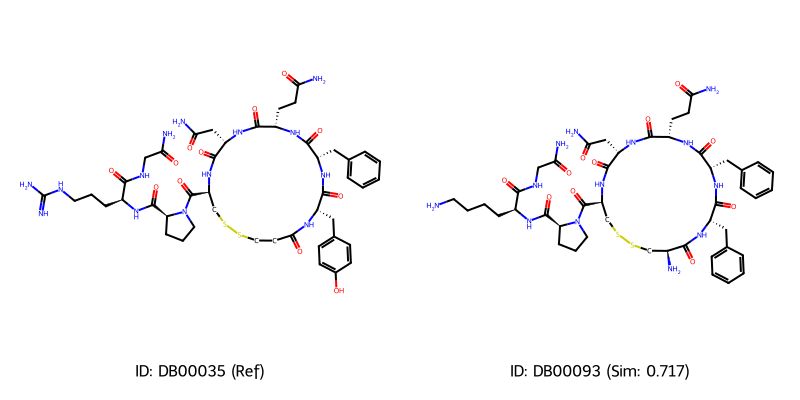

In [8]:
from rdkit.Chem import Draw

def visualize_top_pair(df, matrix, title="Top Similarity Pair"):
    """
    Identifies the most similar pair from a similarity matrix
    and returns an RDKit grid image.
    """
    temp_mat = matrix.copy()
    np.fill_diagonal(temp_mat, 0)
    idx1, idx2 = np.unravel_index(temp_mat.argmax(), temp_mat.shape)

    score = temp_mat[idx1, idx2]

    mols = [df.iloc[idx1]['Mol'], df.iloc[idx2]['Mol']]
    labels = [
        f"ID: {df.iloc[idx1]['drugbank_id']} (Ref)",
        f"ID: {df.iloc[idx2]['drugbank_id']} (Sim: {score:.3f})"
    ]

    print(f"Visualizing {title}...")
    return Draw.MolsToGridImage(
        mols,
        legends=labels,
        molsPerRow=2,
        subImgSize=(400, 400)
    )

img_bit = visualize_top_pair(df, bit_sim, "Most Similar Pair (Bit-based)")
img_bit

So it looks like modified peptides that differ in OH group. Hmmm, let's check if these molecules have the same drug effect.

From Drugbank - vasopressin analogs:
* DB00035 = Desmopressin
    * Vasopressin V2 receptor Agonist
    * used for antidiuretic medication


* DB00093 = Fellypressin
    * Vasopressin V1 receptor Agonist
    * a greater vasoconstrictor activity than antidiuretic action
    * used in local anaesthetic injections for dental use


They are both analogs to vasopressin but used for different purposes.


## MACCS structural keys
Back to MACCS!
Firstly, make our df better (again)...


In [10]:
def get_source(row):
    src = []
    if pd.notna(row['drugbank_id']): src.append('DrugBank')
    if pd.notna(row['ChEMBL ID']): src.append('ChEMBL')
    if pd.notna(row['zincid']): src.append('ZINC')
    return "/".join(src) if src else "Other"

df['Source'] = df.apply(get_source, axis=1)
df

,Canonical_SMILES,drugbank_id,ChEMBL ID,zincid,Mol,Morgan_Bit,Morgan_Count,Source
0,CC[C@H](C)[C@H](NC(=O)[C@H](CCC(=O)O)NC(=O)[C@...,DB02351,NaN,NaN,<rdkit.Chem.rdchem.Mol object at 0x000002443EC...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",<rdkit.DataStructs.cDataStructs.UIntSparseIntV...,DrugBank
1,CC(C)C[C@H](NC(=O)[C@@H](COC(C)(C)C)NC(=O)[C@H...,DB00014,NaN,NaN,<rdkit.Chem.rdchem.Mol object at 0x000002443EC...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",<rdkit.DataStructs.cDataStructs.UIntSparseIntV...,DrugBank
2,N=C(N)NCCC[C@H](NC(=O)[C@@H]1CCCN1C(=O)[C@@H]1...,DB00035,NaN,NaN,<rdkit.Chem.rdchem.Mol object at 0x000002443EC...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",<rdkit.DataStructs.cDataStructs.UIntSparseIntV...,DrugBank
3,CC(=O)N[C@H](Cc1ccc2ccccc2c1)C(=O)N[C@H](Cc1cc...,DB00050,NaN,NaN,<rdkit.Chem.rdchem.Mol object at 0x000002443EC...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",<rdkit.DataStructs.cDataStructs.UIntSparseIntV...,DrugBank
4,C/C=C/C[C@@H](C)[C@@H](O)[C@H]1C(=O)N[C@@H](CC...,DB00091,NaN,NaN,<rdkit.Chem.rdchem.Mol object at 0x000002443EC...,"[0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",<rdkit.DataStructs.cDataStructs.UIntSparseIntV...,DrugBank
...,...,...,...,...,...,...,...,...
18891,CCc1ncc(C(=O)NCC2CCC(NC(=O)c3ncncc3N)CC2)s1,NaN,NaN,ZINCrn00001eRwYj,<rdkit.Chem.rdchem.Mol object at 0x0000024453B...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ...",<rdkit.DataStructs.cDataStructs.UIntSparseIntV...,ZINC
18892,O=C(N[C@]12CCC[C@@H]1N(C[C@@H]1CCCCO1)CC2)c1cc...,NaN,NaN,ZINCsN000009Nrlo,<rdkit.Chem.rdchem.Mol object at 0x0000024453B...,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",<rdkit.DataStructs.cDataStructs.UIntSparseIntV...,ZINC
18893,Cc1ocnc1C(=O)Nc1cccc(CNC(=O)[C@H](C)n2ccc(C3CC...,NaN,NaN,ZINCtB00000oxE6f,<rdkit.Chem.rdchem.Mol object at 0x0000024453B...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, ...",<rdkit.DataStructs.cDataStructs.UIntSparseIntV...,ZINC
18894,CC(C)(CF)C(=O)N1CC2(CC[C@H](CNC(=O)c3ccnc(Cl)c...,NaN,NaN,ZINCrt0000052OFP,<rdkit.Chem.rdchem.Mol object at 0x0000024453B...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",<rdkit.DataStructs.cDataStructs.UIntSparseIntV...,ZINC


And now some plots with MACCS:

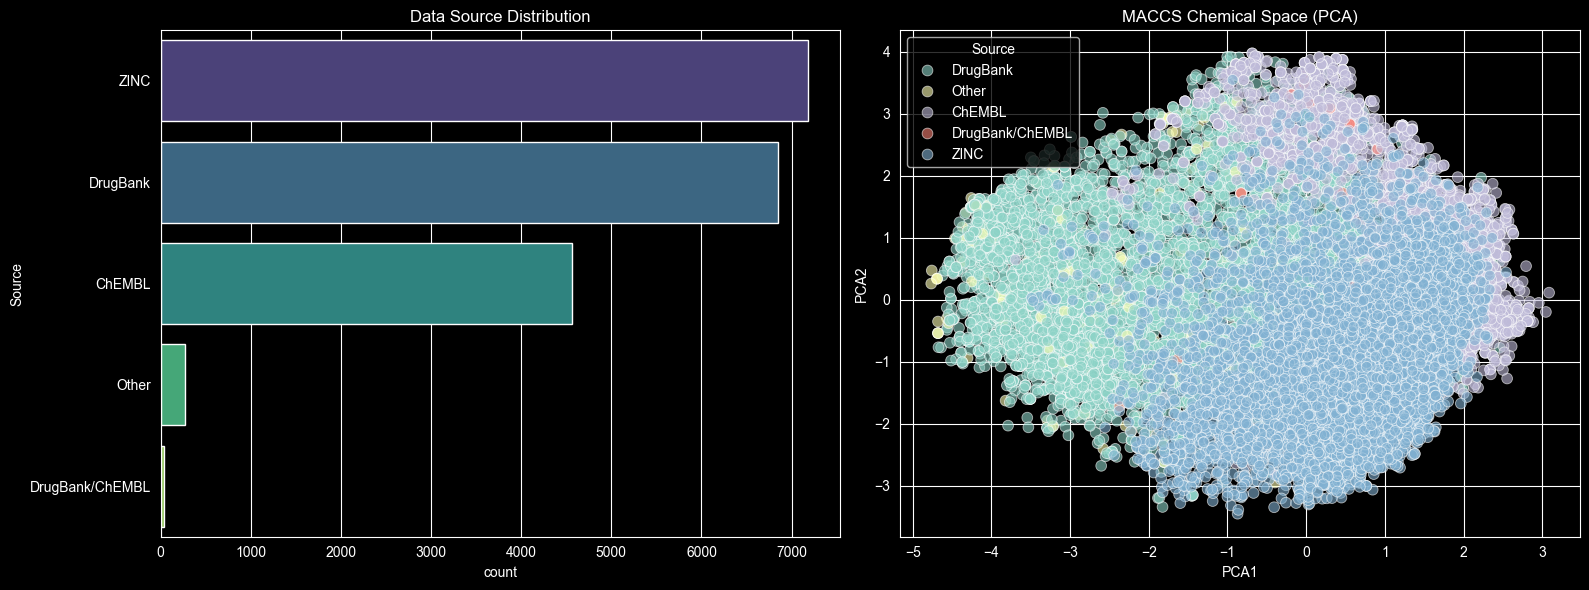

In [12]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

X = np.array(df['MACCS'].tolist())
pca = PCA(n_components=2)
coords = pca.fit_transform(X)
df['PCA1'], df['PCA2'] = coords[:,0], coords[:,1]

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

order = df['Source'].value_counts().index
sns.countplot(data=df, y='Source', order=order, palette='viridis', ax=ax[0])
ax[0].set_title("Data Source Distribution")

sns.scatterplot(data=df, x='PCA1', y='PCA2', hue='Source', alpha=0.6, s=60, ax=ax[1])
ax[1].set_title("MACCS Chemical Space (PCA)")
plt.tight_layout()

From the scatter plot we can see that different datasets come from a different chemical space.

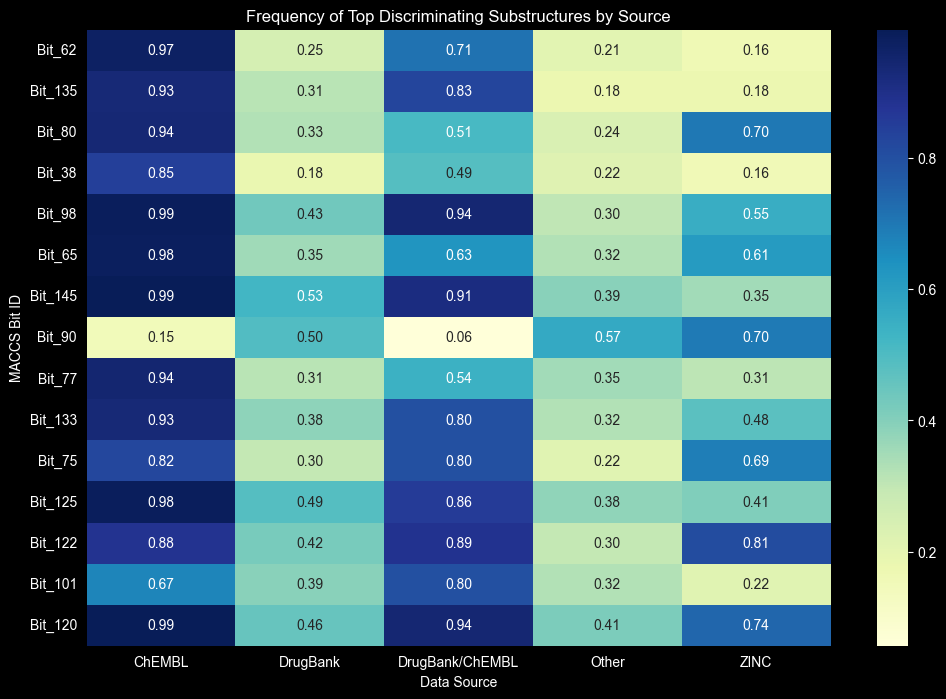

In [13]:
maccs_data = np.array(df['MACCS'].tolist())
bit_cols = [f'Bit_{i}' for i in range(167)]
bit_df = pd.DataFrame(maccs_data, columns=bit_cols)
bit_df['Source'] = df['Source']

# 2. Calculate the mean (frequency) of each bit per source
# A mean of 0.8 means the substructure is present in 80% of that source's molecules
bit_freq = bit_df.groupby('Source').mean()

# 3. Find the most "discriminating" bits
# (Those with the largest difference between the max and min frequency across sources)
bit_variance = bit_freq.max() - bit_freq.min()
top_discriminating_bits = bit_variance.sort_values(ascending=False).head(15).index

# 4. Plot the comparison
plt.figure(figsize=(12, 8))
sns.heatmap(bit_freq[top_discriminating_bits].T, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Frequency of Top Discriminating Substructures by Source")
plt.xlabel("Data Source")
plt.ylabel("MACCS Bit ID")
plt.show()

Hmmm very interesting...